#  IN3050/IN4050 Mandatory Assignment 1: Traveling Salesman Problem


## Rules
Before you begin the exercise, review the rules at this website:
https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html
(This is an individual assignment. You are not allowed to deliver together or copy/share source-code/answers
with others.)

Especially, notice that you are **not allowed to use code or parts of code written by others** in your submission. We do check your code against online repositories, so please be sure to **write all the code yourself**. Any use of **auto-generated code** must be clearly identified, along with the tool or software used to generate it. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Friday, February 23 2024, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

## What to deliver?

Deliver one single zipped folder (.zip, .tgz or .tar.gz) which includes:
* PDF report containing:
    * Your name and username (!)
    * Instructions on how to run your program, with example runs.
    * Answers to all questions from assignment.
    * Brief explanation of what you’ve done.
    * *Your PDF may be generated by exporting your Jupyter Notebook to PDF, if you have answered all questions in your notebook*
* Source code
    * Source code may be delivered as jupyter notebooks or python files (.py)
* The european cities file so the program will run right away.
* Any files needed for the group teacher to easily run your program on IFI linux machines.

**Important**: 
* Include example runs of your code by doing the reports described in the tasks. Simply implementing the code, but never running it will not give many points.
* Include the code that was used to make all reports. Do not include reports of performance and time without also including the code that was used to produce it.
* If you weren’t able to finish the assignment, use the PDF report to elaborate on what you’ve tried
and what problems you encountered. Students who have made an effort and attempted all parts of the assignment
will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

## Introduction
In this exercise, you will attempt to solve an instance of the traveling salesman problem (TSP) using different
methods. The goal is to become familiar with evolutionary algorithms and to appreciate their effectiveness on a
difficult search problem. You have to use Python to solve the assignment. You must write
your program from scratch (but you may use non-EA-related libraries).


|  &nbsp;   | Barcelona | Belgrade |  Berlin | Brussels | Bucharest | Budapest |
|:---------:|:---------:|:--------:|:-------:|:--------:|:---------:|:--------:|
| Barcelona |     0     |  1528.13 | 1497.61 |  1062.89 |  1968.42  |  1498.79 |
|  Belgrade |  1528.13  |     0    |  999.25 |  1372.59 |   447.34  |  316.41  |
|   Berlin  |  1497.61  |  999.25  |    0    |  651.62  |  1293.40  |  1293.40 |
|  Brussels |  1062.89  |  1372.59 |  651.62 |     0    |  1769.69  |  1131.52 |
| Bucharest |  1968.42  |  447.34  | 1293.40 |  1769.69 |     0     |  639.77  |
|  Budapest |  1498.79  |  316.41  | 1293.40 |  1131.52 |   639.77  |     0    |


<center>Figure 1: First 6 cities from csv file.</center>


## Problem
The traveling salesman, wishing to disturb the residents of the major cities in some region of the world in
the shortest time possible, is faced with the problem of finding the shortest tour among the cities. A tour
is a path that starts in one city, visits all of the other cities, and then returns to the starting point. The
relevant pieces of information, then, are the cities and the distances between them. In this instance of the
TSP, a number of European cities are to be visited. Their relative distances are given in the data file, *european_cities.csv*, found in the zip file with the mandatory assignment.

(You will use permutations to represent tours in your programs. The **itertools** module in Python provides
a permutations function that returns successive permutations, this is useful for exhaustive search)

## Helper code for visualizing solutions

Here follows some helper code that you can use to visualize the plans you generate. These visualizations can **help you check if you are making sensible tours or not**. The optimization algoritms below should hopefully find relatively nice looking tours, but perhaps with a few visible inefficiencies.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
np.random.seed(57)
#Map of Europe
europe_map = plt.imread('C:/IN4050/assignment1_2024/map.png')

#C:\IN4050\assignment1_2024
#europe_map =plt.imread('map.png')
#europe_map = plt.imread('C:/Users/Malin Storm/Desktop/IN4050/assignment1/Assignment1/map.png') 

#Lists of city coordinates
city_coords = {
    "Barcelona": [2.154007, 41.390205], "Belgrade": [20.46, 44.79], "Berlin": [13.40, 52.52], 
    "Brussels": [4.35, 50.85], "Bucharest": [26.10, 44.44], "Budapest": [19.04, 47.50],
    "Copenhagen": [12.57, 55.68], "Dublin": [-6.27, 53.35], "Hamburg": [9.99, 53.55], 
    "Istanbul": [28.98, 41.02], "Kyiv": [30.52, 50.45], "London": [-0.12, 51.51], 
    "Madrid": [-3.70, 40.42], "Milan": [9.19, 45.46], "Moscow": [37.62, 55.75],
    "Munich": [11.58, 48.14], "Paris": [2.35, 48.86], "Prague": [14.42, 50.07],
    "Rome": [12.50, 41.90], "Saint Petersburg": [30.31, 59.94], "Sofia": [23.32, 42.70],
    "Stockholm": [18.06, 60.33], "Vienna": [16.36, 48.21], "Warsaw": [21.02, 52.24]}


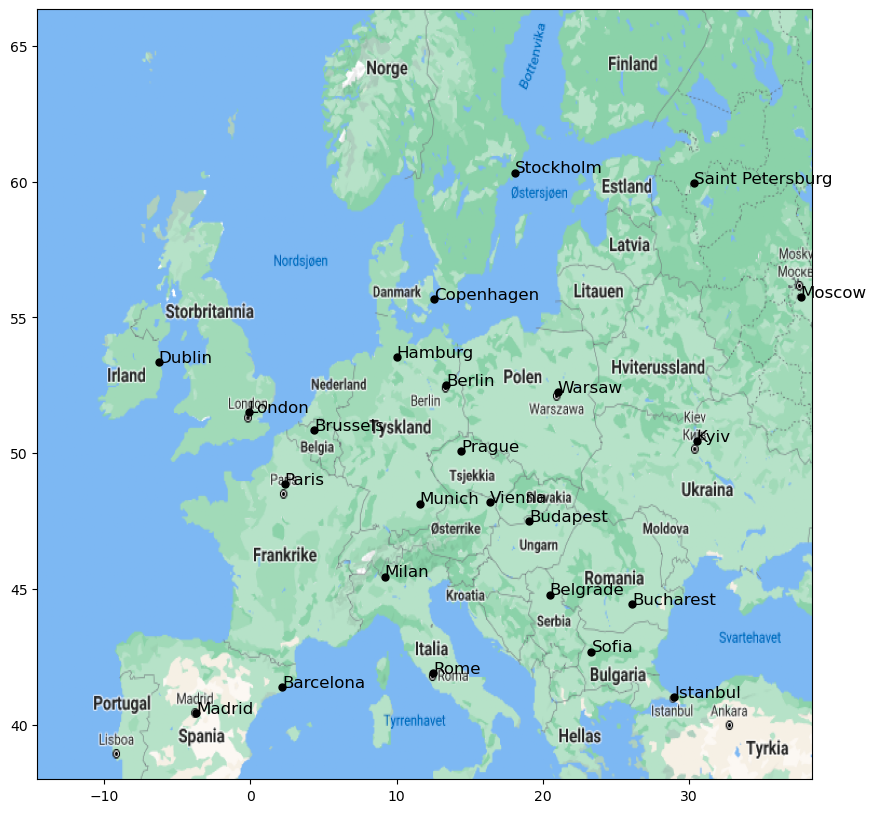

In [2]:
#Helper code for plotting plans
#First, visualizing the cities.
import csv
with open("C:/IN4050/assignment1_2024/european_cities.csv", "r") as f:
    data = list(csv.reader(f, delimiter=';'))
    cities = data[0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(europe_map, extent=[-14.56, 38.43, 37.697 + 0.3, 64.344 + 2.0], aspect="auto")

# Map (long, lat) to (x, y) for plotting
for city, location in city_coords.items():
    x, y = (location[0], location[1])
    plt.plot(x, y, 'ok', markersize=5)
    plt.text(x, y, city, fontsize=12)


In [3]:
#A method you can use to plot your plan on the map.
def plot_plan(city_order):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(europe_map, extent=[-14.56, 38.43, 37.697 + 0.3, 64.344 + 2.0], aspect="auto")

    # Map (long, lat) to (x, y) for plotting
    for index in range(len(city_order) - 1):
        current_city_coords = city_coords[city_order[index]]
        next_city_coords = city_coords[city_order[index+1]]
        x, y = current_city_coords[0], current_city_coords[1]
        #Plotting a line to the next city
        next_x, next_y = next_city_coords[0], next_city_coords[1]
        plt.plot([x, next_x], [y, next_y])

        plt.plot(x, y, 'ok', markersize=5)
        plt.text(x, y, index, fontsize=12)
    #Finally, plotting from last to first city
    first_city_coords = city_coords[city_order[0]]
    first_x, first_y = first_city_coords[0], first_city_coords[1]
    plt.plot([next_x, first_x], [next_y, first_y])
    #Plotting a marker and index for the final city
    plt.plot(next_x, next_y, 'ok', markersize=5)
    plt.text(next_x, next_y, index+1, fontsize=12)
    plt.show()


['Barcelona', 'Belgrade', 'Berlin', 'Brussels', 'Bucharest', 'Budapest', 'Copenhagen', 'Dublin', 'Hamburg', 'Istanbul', 'Kyiv', 'London', 'Madrid', 'Milan', 'Moscow', 'Munich', 'Paris', 'Prague', 'Rome', 'Saint Petersburg', 'Sofia', 'Stockholm', 'Vienna', 'Warsaw']


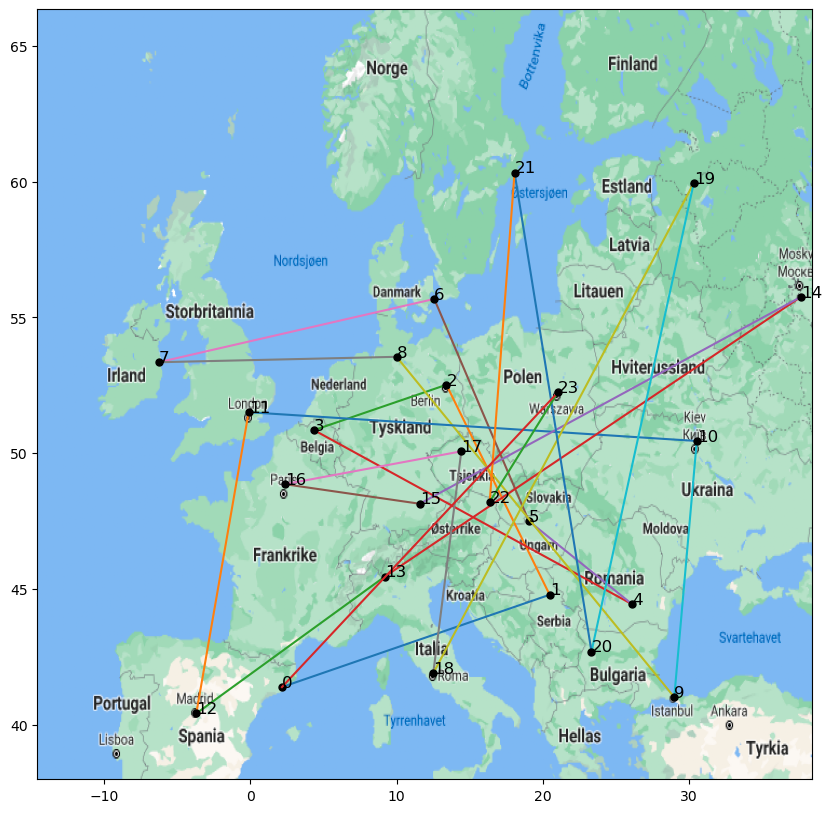

In [4]:
#Example usage of the plotting-method.
plan = list(city_coords.keys()) # Gives us the cities in alphabetic order
print(plan)
plot_plan(plan)

## Exhaustive Search
First, try to solve the problem by inspecting every possible tour. Start by writing a program to find the shortest
tour among a subset of the cities (say, **6** of them). Measure the amount of time your program takes. Incrementally
add more cities and observe how the time increases. Plot the shortest tours you found using the plot_plan method above, for 6 and 10 cities.

**Note:** To get distances between cities, use the dictionary `data` created by reading the file `european_cities.csv`. *Do not* calculate distances based on the coordinates. The actual distances do not only depend on the differences in the coordinates, but also of the curvature of the earth. The distances available in `data` are corrected for this, and contain the actual true distances.

In [5]:
# function that sums the total distance for each permutation

def calculate_total_dist(permutation):
    
    sum = 0 # set to zero for each permutation
    
    # summing the distances between the cities in the permutation stepwise
    for i in range(len(permutation)-1):
        sum += calculate_dist(permutation[i],permutation[i+1])
    
    sum += calculate_dist(permutation[0],permutation[-1]) # adds the trip back to the origin
    
    return sum

# function that iterates over each permutation

def iterate_permutation(subset):
    best = 100000 # initial best distance (set high) 
    best_permutation = None
    start_time = time.time()
    
    for permutation in it.permutations(subset): # iterating the permutations
                  
        current = calculate_total_dist(permutation) # saving the current distance
        
        # checking if current distance is shorter than best 
        if current < best:
            best = current
            best_permutation = permutation
        
    end_time = time.time()
    timer = round(end_time - start_time,2) 
    
    
    return best, best_permutation, timer
        
    
# function that do calculations bit by bit

def calculate_dist(index1,index2):
    return float(data[index1 + 1][index2])

# function that makes returns a list of indexes that map to the cities we want to run the TSP on

def make_subset(seed, cities):
    
    subset = [] # making a subset of the number of cities you want to implement the problem on
    for city in range(seed):
        subset.append(cities[city])
    
    sub_index = [] # converting the subset-names to indexes
    for i in subset:
        sub_index.append(subset.index(i))

    return sub_index
    

Time the algorithm uses to run through 6 cities =  0.0 s
Total distance travelled =  5018.81 km


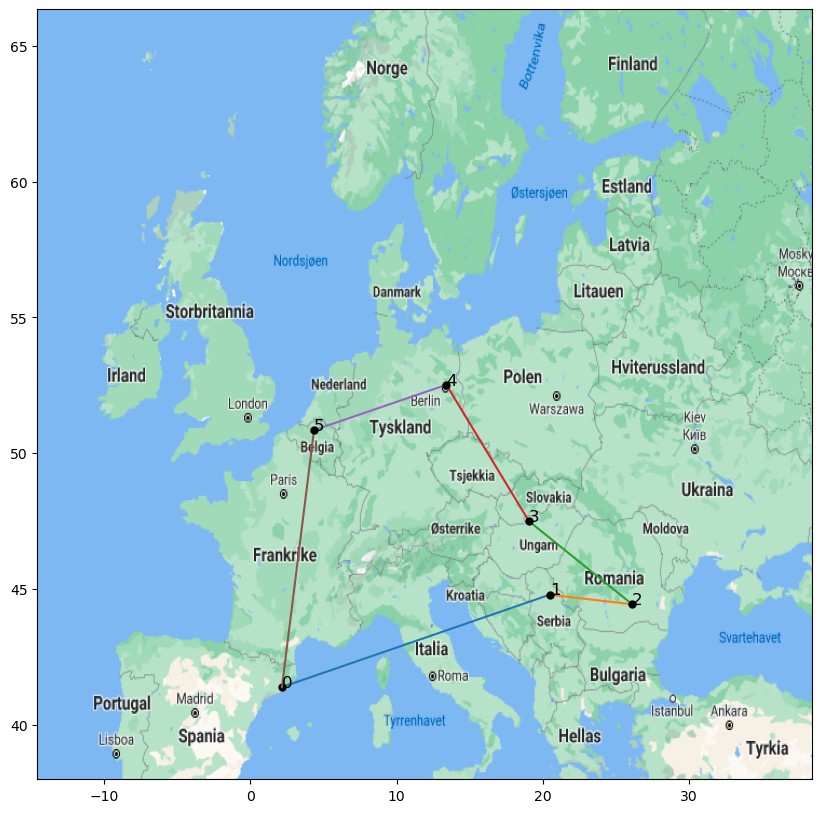

beste tur ['Barcelona', 'Belgrade', 'Bucharest', 'Budapest', 'Berlin', 'Brussels']


In [6]:
####################### EXHAUSTIVE SEARCH ################################################

# Implement the algorithm here

#husk å starte med samme startby, husk å regne avstanden tilbake til start

#print(data[1]) # dette er alle avstandene relativt til barcelona

import time
import itertools as it 

cities = data[0]

seed = 6 # the number of cities the TSP has to traverse

subset = make_subset(seed, cities) # the subset we want to make permutations of, returns a list of indexes

best, best_permutation, timer = iterate_permutation(subset) # calling function that checks for the best solution

print("Time the algorithm uses to run through",seed,"cities = ",timer, "s")
print("Total distance travelled = ", round(best,2), "km")

# converting the best_permutation back to a city name, so that plot_plan can run
best_trip = []
for i in best_permutation:
    best_trip.append(data[0][i])
#plotting the plan
plot_plan(best_trip)
print("beste tur", best_trip)
    



What is the shortest tour (i.e., the actual sequence of cities, and its length) among the first 10 cities (that is,
the cities starting with B,C,D,H and I)? How long did your program take to find it? Calculate an approximation of how long it would take to perform exhaustive search on all 24 cities?

In [7]:
# Answer

#Time the algorithm uses to run through 10 cities = 8.62 s
#Total distance travelled = 7486.31 km

#6! = 720 = 0.000001 s
#10! = 3628800 = 8.62 s
#24! = 6.204484e+23 = x s

# x/6.204484e+23 = 8.62/3628800

# x = 8.62*6.204484e+23/3628800




## Hill Climbing
Then, write a simple hill climber to solve the TSP. How well does the hill climber perform, compared to the result from the exhaustive search for the first **10 cities**? Since you are dealing with a stochastic algorithm, you
should run the algorithm several times to measure its performance. Report the length of the tour of the best,
worst and mean of 20 runs (with random starting tours), as well as the standard deviation of the runs, both with the **10 first cities**, and with all **24 cities**. Plot one of the the plans from the 20 runs for both 10 cities and 24 cities (you can use plot_plan). 

In [8]:
# function that searches for the best permutation and records time taken for each run
def best_permutation(rand):

    
    start_time = time.time()

    # calling swap_index function, that generates a swapped permutation
    swap = swap_index(rand)

    current = calculate_total_dist(swap) # calculating tot dist for the permutation

    end_time = time.time()
    timer = round(end_time - start_time,10) # calculate the time taken to run the permutation

    return current, swap, timer

# function that swaps two random indexes in a subset
def swap_index(subset):
    
    index = random.sample(range(0,len(subset)-1),2) # generating 2 random indexes in a given range
    
    swap = subset.copy()
    swap[index[0]], swap[index[1]] = subset[index[1]],subset[index[0]] # swapping the 2 indexes
    
    
    return swap



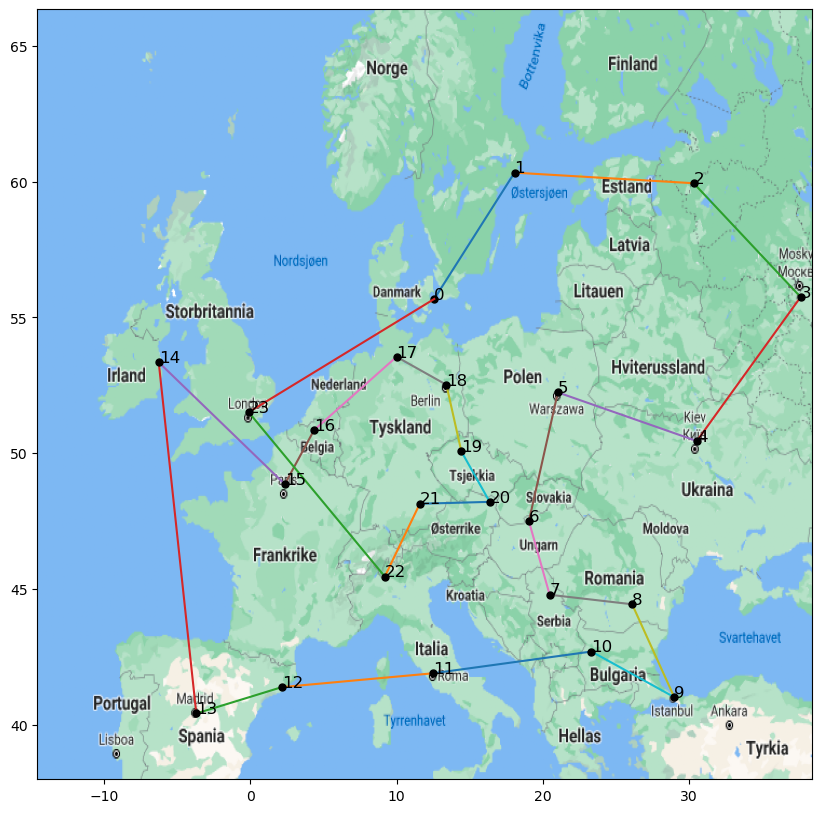

 Best route found: 14181.74 km 
 Worst route found: 34857.45 km 
 STD: 141.12 km 
 Mean: 19914.48 km 
 0.0023 s


In [7]:
# Implement the algorithm here

import random
import numpy as np
import time

#parameters
seed = 24 # number of cities
runs = 600 # the number of times you want the algorithm to run
sum = 0.0
best = 100000 # (set high)
worst = 0
best_time = 0.0
time_now = 0.0
std_list = []
rand = random.sample(range(seed), seed) # generating random list, no duplicates


for i in range(runs):
    
    # calls function that searchs for best permutation
    current, swap, timer = best_permutation(rand) 
    time_now += timer # sums the time taken for each round
    
    # checks if current calculation is better/worse than previous calculations
    if current < best:
        best = current
        best_perm = swap
        rand = swap # saves the permutation to variable rand, so that best_permutation() is called with this permutation
        
    else:       
        if current > worst:
            worst = current
            worst_perm = swap
    
    best_time += time_now # sums the the time taken until alghorithm finds a best solution / local optima
   
    sum += current # sums distance of all trips

average = float(sum/runs) # calculates average distance travelled
std = np.sqrt(average) # calculates standard deviation
best_time = float(best_time/runs)

# converting indexes to City names and plotting the best trip / local optima
best_trip = []
for i in best_perm:
    best_trip.append(data[0][i])
#plotting the plan
plot_plan(best_trip)


print(" Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n","Mean:",round(average,2),"km","\n",round(best_time,4),"s")




## Genetic Algorithm
Next, write a genetic algorithm (GA) to solve the problem. Choose mutation and crossover operators that are appropriate for the problem (see chapter 4.5 of the Eiben and Smith textbook). Choose three different values for the population size. Define and tune other parameters yourself and make assumptions as necessary (and report them, of course).

For all three variants: As with the hill climber, report best, worst, mean and standard deviation of tour length out of 20 runs of the algorithm (of the best individual of last generation). Also, find and plot the average fitness of the best fit individual in each generation (average across runs), and include a figure with all three curves in the same plot in the report. This means that the x-axis should be the generations over time and the y-axis should be the average (over the 20-runs) fitness of the best gene in that generation. Conclude which is best in terms of tour length and number of generations of evolution time.

Finally, plot an example optimized tour (the best of the final generation) for the three different population sizes, using the plot_plan method.

In [10]:
# algorithm for crossing
def parents(individual):
    
    index = random.sample(range(1,len(individual[0])-1),2) # random genrate indexes to form a range
    crossover = [] # list for storing crossed individuals
    
    if index[0] > index[1]: # making sure the range ascending
        index[0], index[1] = index[1], index[0]
    
    
    for parent in range(1,len(individual)+1): # looping through elements of individual list
       
        parent1 = individual[parent-1]
    
        for parent_crossover in range(1,len(individual)+1): # breeding with all elements of list
                
            parent2 = individual[parent_crossover-1] # 
            
            if parent1 != parent2: # breeding only on solutions that are different
                # slicing parent-arrays from according to index 
                slice1 = parent1[index[0]:index[1] + 1] 
                slice2 = parent2[index[0]:index[1] + 1] 
                child = parent2.copy()
                
                
                for i in range(index[0],len(slice1)+index[0]): # jump into the right index
                    
                    # checking that elements are different (if else they won't be swapped)
                    if slice1[i-index[0]] != parent2[i]:
                            
                        for j in range(len(slice1)):
                            # checking that element is not already in swat (on a different index)
                            if slice1[j] not in slice2:
                                for k in range(len(child)): 
                                    if child[k] == slice1[j]:
                                        # swapping elements of list
                                        child[k],child[j+index[0]] = child[j+index[0]],child[k]
                            else: # if element is member of swat
                                for k in range(len(child)):
                                    if child[k] == slice1[j]:
                                        child[k],child[j+index[0]] = child[j+index[0]],child[k]
                        
                crossover.append(child)
            
            else: crossover.append(parent1) # making sure that crossover not empty
    
    return crossover

def roulette(sum_of_individual,generation): 
    
    pick = random.uniform(0,sum_of_individual) # generate a possibility for beeing picked, inbetween zero and sum of whole generation
    
    distance = [] # list for each distance
    
    for i in range(len(generation)):
        distance.append(calculate_total_dist(generation[i]))
    
    individual = []
    current = 0
    for i in range(len(generation)):
        selection_fitness = distance[i]  
        current += selection_fitness
        if current > pick: # if it is above the random generated fitness, it will be selected
            individual.append(generation[i])
          
    if len(individual) > 1:   
        return individual
    else:
        return generation#[0:int(len(generation)*0.5)] #make sure a proportion of the best is returned, if there are < 2 crossovers
    
# picks out mutated individuals
def mutation(crossover, mutation_rate):
    
    mutated = []
    crossover_copy = crossover.copy() # copy of crossover
    count = 0
    for i in crossover_copy:
        pick = random.uniform(0,1) # prob 0-1
        if pick <= mutation_rate: # if pick has same or lower possibility
            crossover.remove(i)
            mutated.append(swap_index(i)) # swaps indexes
            count += 1
   
    return mutated,crossover
            

# calculates sum of distances generation
def fitness(distance):
    
    sum_f = 0
    for i in range(len(distance)):
        sum_f += distance[i]
    
    average_fit = float(sum_f/len(distance))
    
    return sum_f,average_fit
  

# sorting distances ascending
def sort_generation(generation, k):
    
    distance = []
    
    for i in range(k):
        distance.append(calculate_total_dist_GA(generation[i]))
   
    distance.sort()
   
    return distance

# function that sums the total distance for each permutation

def calculate_total_dist_GA(permutation):
    
    sum = 0 # set to zero for each permutation
   
    # summing the distances between the cities in the permutation stepwise
    for i in range(len(permutation)-1):
        sum += calculate_dist_GA(permutation[i],permutation[i+1])
    
    sum += calculate_dist_GA(permutation[0],permutation[-1]) # adds the trip back to the origin
   
    return sum

# function that do calculations bit by bit

def calculate_dist_GA(index1,index2):
    
    return float(data[index1 + 1][index2])

    
        

In [11]:
def merge_sort(permutations):
    
    
    if len(permutations) > 1: # if not, there is nothing more to do about the list
        
        # cutting the list in two halves
        list_L = permutations[:len(permutations)//2]
        list_R = permutations[len(permutations)//2:]
        
        # recursion
        merge_sort(list_L)
        merge_sort(list_R)
        i,j,k = 0,0,0
        
        # checking which index in permutation has the shortest distance
        while i < len(list_L) and j < len(list_R):
            if calculate_total_dist_GA(list_L[i]) < calculate_total_dist_GA(list_R[j]):  #if list_L[i] < list_R[j]:
                permutations[k] = list_L[i]
                i += 1
            else:
                permutations[k] = list_R[j]
                j += 1
            k += 1
        # checking if there are any indexes left placing in list
        while i < len(list_L):
            permutations[k] = list_L[i]
            i += 1
            k += 1
        while j < len(list_R):
            permutations[k] = list_R[j]
            j += 1
            k += 1
        
    
    return permutations    


In [12]:
# calculates best, worst, sum, average, std
def best_worst(permutations,best,worst):
    
    sum = 0
    average_gen = 0
    std_gen = 0
    best_perm,worst_perm = [],[]
    
    perm_sorted = merge_sort(permutations)#generation_sorting(permutations) # sorts permutations ascending
    distance_sorted = sort_generation(perm_sorted,len(perm_sorted)) # finds all distances in generation, sorted ascending
    
    for i in range(len(permutations)):
        
        current = distance_sorted[i]
    
    # checks if current calculation is better/worse than previous calculations
        if current < best:
            best = current
            best_perm = perm_sorted[i]
            
        else:       
            if current > worst:
                worst = current
                worst_perm = perm_sorted[i]
       
        sum += current # sums distance of all trips
          
      
    average_gen = float(sum/len(permutations)) # average of generation
    std_gen = np.sqrt(average_gen) # calculates standard deviation
                    
    return best,worst,best_perm,worst_perm,average_gen,std_gen, distance_sorted[0] 

In [13]:
def new_generation_proportions(k,crossover,mutated,prop_parents = 0.4,prop_crossover = 0.5): # changing for each generation
    
    # fractions of population number to pick parents, crossings
    num_parents = int(prop_parents*k) 
    num_crossover = int(prop_crossover*k)
    
    if num_crossover > len(crossover): # om det ikke er generert nok krysninger
        num_crossover = len(crossover)
    
    num_mutated = k - num_parents - num_crossover # need number of crossovers to calc num mutated

    if num_mutated > len(mutated): # om det ikke er generart nok mutasjoner
        num_mutated = len(mutated)
        num_parents = k - num_crossover - num_mutated
    
    return num_parents,num_crossover,num_mutated

In [14]:
def plot(population1,population2,population3,runs):
    
    generation_list = np.arange(0,runs,1)
    
    plt.plot(generation_list,population1,'g')
    plt.plot(generation_list,population2,'b')
    plt.plot(generation_list,population3,'r')
    plt.ylabel('Average Fitness')
    plt.xlabel('Runs')
    plt.axis([0,runs-1,0,35000])
    plt.legend(["Population1","Population2","Population3"])
    plt.show()

In [15]:
def making_initial_gen(k,size):
    
    generation = []
    
    # making initial generation
    for i in range(k):
        generation.append(random.sample(range(size), size)) 

    sorted_generation = merge_sort(generation) # sorting for genotype, [1,3,4,2,7,6,...] 
    # variables for storing best/worst, starting from first generation
    best_genotyp = sorted_generation[0]
    worst_genotyp = sorted_generation[k-1]
    # distances sorted
    best_list = sort_generation(sorted_generation,k) 
    best,best_individual_gen = best_list[0], best_list[0]
    worst = best_list[k-1]

    return sorted_generation,best_genotyp,worst_genotyp,best_list,best, best_individual_gen


In [13]:
import random
import numpy as np
import time
from sklearn import preprocessing

population1,population2,population3 = [],[],[]
k1,k2,k3 = 15,30,50 # population size
size = 24 # NUM CITIES
runs,gen = 20,50 
prop_parents, prop_crossover = 0.2,0.7 # parameters for selection survivor-generation
mutation_rate = 0.1 # probability for mutation

population1,best_genotyp1,best,worst,average,std,timer = run_algorithm(k1,size,mutation_rate,runs,gen,prop_parents,prop_crossover)
best_average_fitness = 0#float(best_average_fitness/runs)

best_trip_GA1 = []
for i in best_genotyp1:
    best_trip_GA1.append(data[0][i])
    
print("Population size: ",k1," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
      "Mean:",round(average,2),"km","\n",
      round(timer,2),"s","\n")

population2,best_genotyp2,best,worst,average,std,timer = run_algorithm(k2,size,mutation_rate,runs,gen,prop_parents,prop_crossover)

best_trip_GA2 = []
for i in best_genotyp2:
    best_trip_GA2.append(data[0][i])
    
print("Population size: ",k2," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
      "Mean:",round(average,2),"km","\n",
      round(timer,2),"s","\n")

population3,best_genotyp3,best,worst,average,std,timer = run_algorithm(k3,size,mutation_rate,runs,gen,prop_parents,prop_crossover)

print("Population size: ",k3," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
      "Mean:",round(average,2),"km","\n",
      round(timer,2),"s","\n")
best_trip_GA3 = []
for i in best_genotyp3:
    best_trip_GA3.append(data[0][i])

# plotting the chart with best average fitness    

plot(population1,population2,population3,runs)
    
#plotting the plan
plot_plan(best_trip_GA1)
#plotting the plan
plot_plan(best_trip_GA2)
#plotting the plan
plot_plan(best_trip_GA3)


    
    
    
    
    
    

In [16]:

import random
import numpy as np
import time
from sklearn import preprocessing

def run_algorithm(k,size,mutation_rate,runs,gen,prop_parents,prop_crossover):
        
    average,std,best,worst,average_sum,average_fitness,best_average_fitness, average_fitness_list = 0,0,0,0,0,100000,0,[]
    best_time, time_now,timer = 0.0,0.0,0.0
    start_time = time.time() # starting timer
    average_fitness_list = [] # to store list for print average fitness

    for j in range(runs):
        
        
        best_individual_gen = 0
        # making initial generation
        sorted_generation,best_genotyp,worst_genotyp,best_list,best, best_individual_gen = making_initial_gen(k,size) # random generate init population that will be improved gen times
        sum = 0
        
        for m in range(gen):
            
            distance =  sort_generation(sorted_generation,k) # sorting for fenotype, ascending order
        
            sum_of_individuals,average_fit = fitness(distance) # sums distances of generation
            #sum_of_individuals = fitness(distance) # sums distances of generation
            individual = roulette(sum_of_individuals,sorted_generation) # generates list of individuals that will cross, best fitness
    
            crossover = parents(individual) # calling breeding function
    
            mutated_individuals, crossover = mutation(crossover,mutation_rate) # picks out mutated individuals
        
        
            if len(crossover) != 0: # check that lists are not empty
        
                crossover_sorted = merge_sort(crossover) #survivors_crossover(crossover) 
           
                if not(len(mutated_individuals)) == 0: # checks that list are not empty
                    mutated_sorted = merge_sort(mutated_individuals) #survivor_mutated(mutated_individuals) 
                else: mutatet_sorted = [0]
                    
                # calculating different numbers of parents, crossover and mutated each round
                num_parents,num_crossover,num_mutated = new_generation_proportions(k,crossover_sorted,mutated_sorted)
        
                # adding to/deleting from pool
                for i in range(0,num_mutated):                
                    sorted_generation.insert(0,mutated_sorted[i])                 
                for i in range(0,num_crossover):                              
                    sorted_generation.insert(0,crossover_sorted[i])                                          
                for i in range(0,num_parents):                                 
                    sorted_generation.insert(0,sorted_generation[i])                                           
        
        
                sorted_generation = merge_sort(sorted_generation) #generation_sorting(sorted_generation) # sorting generation in ascending order befor      e slicing
            
                distance =  sort_generation(sorted_generation,k) # sorting for fenotype, ascending order
                # setting the generation to number of permutations = k with slicing 
                del sorted_generation[k:len(sorted_generation)]
                
                # calling best_worst() 
                best_temp,worst_temp,best_perm,worst_perm,average_gen,std,best_individual_gen = best_worst(sorted_generation,best,worst)
                
            
                if best_temp < best: # if km are less
                    best = best_temp 
                    best_genotyp = best_perm # setting the genotyp ([0,1,3,7,6,....])
            
                if worst_temp > worst:
                    worst = worst_temp
                    worst_genotyp = worst_perm
                
                sum += best_individual_gen # best individual/gen summed up
                   
               
           
            average_sum += best_temp
                
        average_fitness_list.append(float(sum/gen)) # average of best individuals/num_generations, best avereage fitness
            
        end_time = time.time()
        timer = round(end_time - start_time,2) # calculate the time taken to run the permutation
      
        average = float(average_sum/gen/runs) #float(average_sum/runs)
        std = np.sqrt(average)
    
    return average_fitness_list,best_genotyp,best,worst,average,std,timer 




Among the first 10 cities, did your GA find the shortest tour (as found by the exhaustive search)? Did it come close? 

For both 10 and 24 cities: How did the running time of your GA compare to that of the exhaustive search? 

How many tours were inspected by your GA as compared to by the exhaustive search?

In [ ]:
# Answer

## Hybrid Algorithm (IN4050 only)
### Lamarckian
Lamarck, 1809: Traits acquired in parents’ lifetimes can be inherited by offspring. In general the algorithms are referred to as Lamarckian if the result of the local search stage replaces the individual in the population.
### Baldwinian
Baldwin effect suggests a mechanism whereby evolutionary progress can be guided towards favourable adaptation without the changes in individual's fitness arising from learning or development being reflected in changed genetic characteristics. In general the algorithms are referred to as Baldwinian if the original member is kept, but has as its fitness the value belonging to the outcome of the local search process.


(See chapter 10 and 10.2.1 from Eiben and Smith textbook for more details. It will also be lectured in Lecure 4)

### Task
Implement a hybrid algorithm to solve the TSP: Couple your GA and hill climber by running the hill climber a number of iterations on each individual in the population as part of the evaluation. Test both Lamarckian and Baldwinian learning models and report the results of both variants in the same way as with the pure GA (min,
max, mean and standard deviation of the end result and an averaged generational plot). How do the results compare to that of the pure GA, considering the number of evaluations done?

In [17]:
def lamarckian(generation):
   
    #calls function that searchs for best permutation by swapping indexes on individual
    for i in range(len(generation)):
        swap_feno, swap_geno = best_permutation_Lamarck(generation[i]) 
        
        if swap_feno < calculate_total_distance_Lamarck(generation[i]): # if distance is less
            generation.insert(i,swap_geno) # insert element
            del generation[i+1] # delete element
            
    
    return generation

In [36]:
def baldwian(generation):
    
       
    best_fitness_perm = []
    #best_fitness = []
    best_fitness =  sort_generation(generation,len(generation)) # sorting for fenotype, ascending order
    
    #calls function that searchs for best permutation by swapping indexes on individual
    for i in range(len(generation)):
        swap_feno, swap_geno = best_permutation_Lamarck(generation[i]) 
        
        if swap_feno < calculate_total_distance_Lamarck(generation[i]): # if distance is less
           
            best_fitness_perm.append(swap_geno)
            best_fitness.insert(i,swap_feno) # insert element
            del best_fitness[i+1] # delete element
            
        
            
    return best_fitness,best_fitness_perm

In [19]:
# function that  permutation
def best_permutation_Lamarck(perm):

    # calling swap_index function, that generates a list of swapped permutations
    swap_geno = swap_index_Lamarck(perm)

    swap_feno = calculate_total_distance_Lamarck(swap_geno) # calculating tot dist for the permutation

    return swap_feno, swap_geno 

# function that swaps two random indexes in a subset
def swap_index_Lamarck(subset):
    
    index = random.sample(range(0,len(subset)-1),2) # generating 2 random indexes in a given range
    
    swap = subset.copy()
    swap[index[0]], swap[index[1]] = subset[index[1]],subset[index[0]] # swapping the 2 indexes
    
    
    return swap


In [20]:
# function that sums the total distance for each permutation

def calculate_total_distance_Lamarck(permutation):
    
    sum = 0 # set to zero for each permutation
    
    # summing the distances between the cities in the permutation stepwise
    for i in range(len(permutation)-1):
        sum += calculate_dist_GA(permutation[i],permutation[i+1])
    
    sum += calculate_dist_GA(permutation[0],permutation[-1]) # adds the trip back to the origin
    
    return sum

# function that do calculations bit by bit

def calculate_dist_Lamarck(index1,index2):
   
    return float(data[index1 + 1][index2])


Population size:  15  Best route found: 15752.75 km 
 Worst route found: 32352.18 km 
 STD: 134.19 km 
 Mean: 18007.11 km 
 7.66 s 

Population size:  30  Best route found: 14401.28 km 
 Worst route found: 34250.56 km 
 STD: 131.13 km 
 Mean: 17194.48 km 
 29.24 s 

Population size:  50  Best route found: 13044.27 km 
 Worst route found: 32876.0 km 
 STD: 129.84 km 
 Mean: 16857.87 km 
 83.74 s 



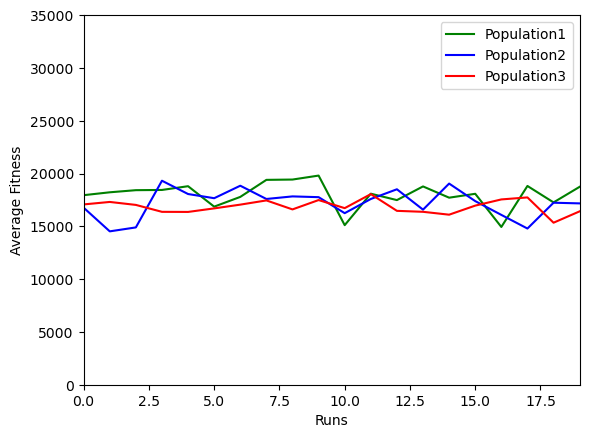

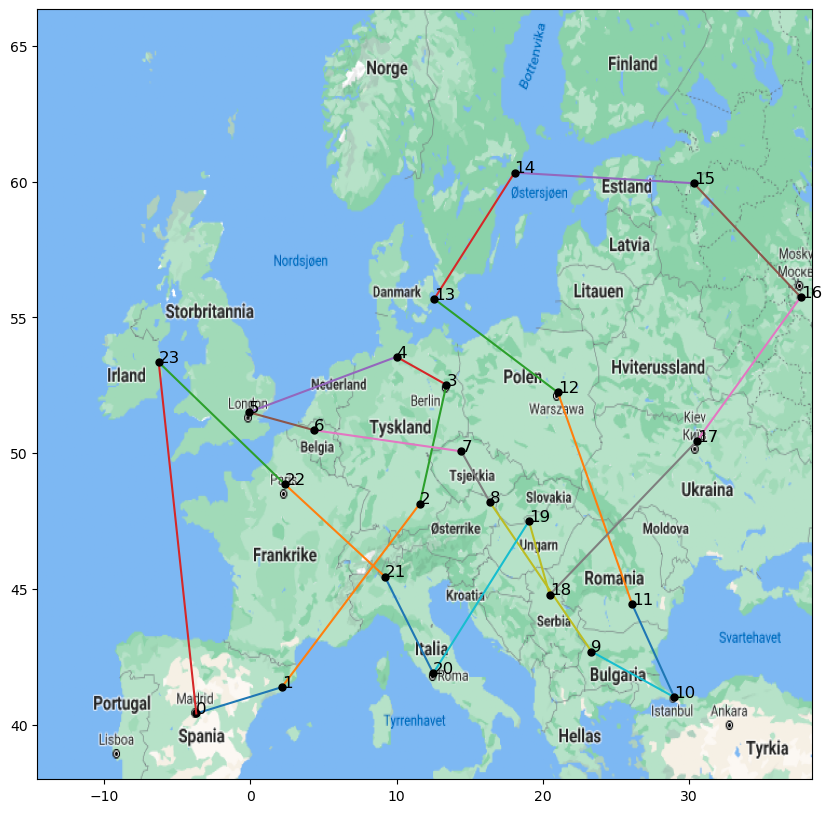

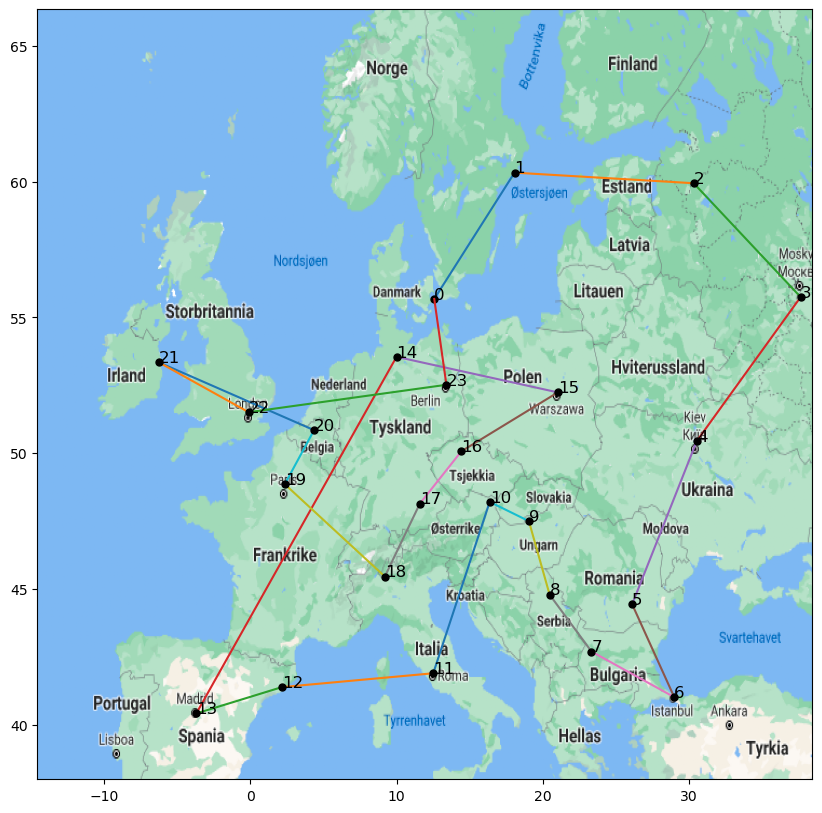

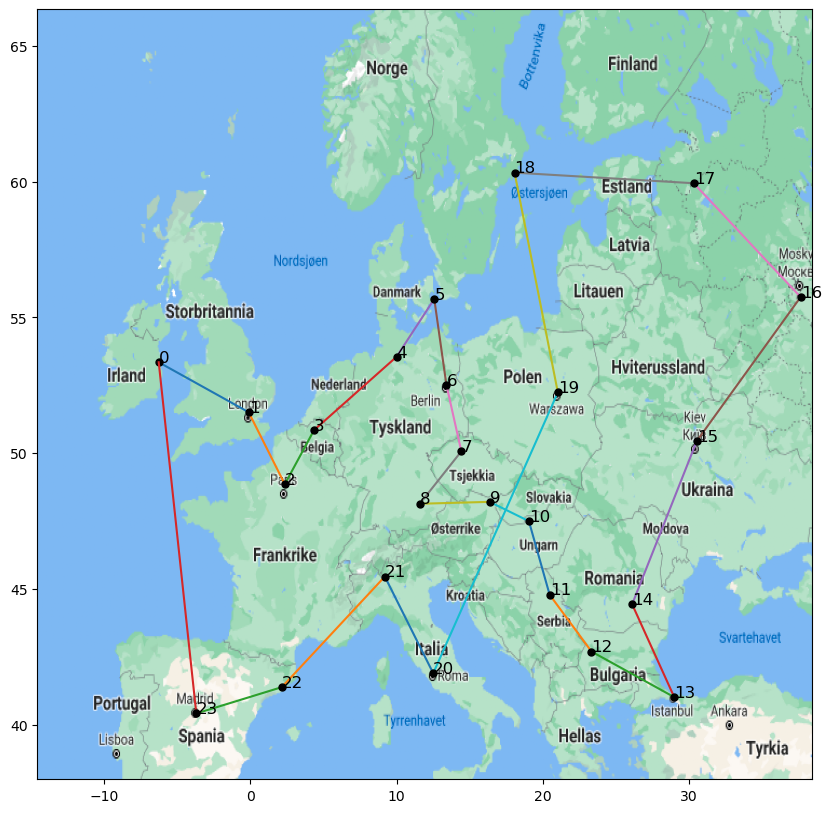

In [34]:
import random
import numpy as np
import time
from sklearn import preprocessing

population1,population2,population3 = [],[],[]
k1,k2,k3 = 15,30,50 # population size
size = 24 # NUM CITIES
runs,gen = 20,50
prop_parents, prop_crossover = 0.2,0.7 # parameters for selection survivor-generation
mutation_rate = 0.1 # probability for mutation

population1,best_genotyp1,best,worst,average,std,timer = run_algorithm_Lamarck(k1,size,mutation_rate,runs,gen,prop_parents,prop_crossover)


best_trip_GA1 = []
for i in best_genotyp1:
    best_trip_GA1.append(data[0][i])
    
print("Population size: ",k1," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
      "Mean:",round(average,2),"km","\n",round(timer,2),"s","\n")

population2,best_genotyp2,best,worst,average,std,timer = run_algorithm_Lamarck(k2,size,mutation_rate,runs,gen,prop_parents,prop_crossover)

best_trip_GA2 = []
for i in best_genotyp2:
    best_trip_GA2.append(data[0][i])
    
print("Population size: ",k2," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
     "Mean:",round(average,2),"km","\n",round(timer,2),"s","\n")

population3,best_genotyp3,best,worst,average,std,timer = run_algorithm_Lamarck(k3,size,mutation_rate,runs,gen,prop_parents,prop_crossover)

print("Population size: ",k3," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
     "Mean:",round(average,2),"km","\n", round(timer,2),"s","\n")
best_trip_GA3 = []
for i in best_genotyp3:
    best_trip_GA3.append(data[0][i])

#plotting the chart with best average fitness    

plot(population1,population2,population3,runs)
    
#plotting the plan
plot_plan(best_trip_GA1)
#plotting the plan
plot_plan(best_trip_GA2)
#plotting the plan
plot_plan(best_trip_GA3)


In [21]:
import random
import numpy as np
import time
from sklearn import preprocessing

def run_algorithm_Lamarck(k,size,mutation_rate,runs,gen,prop_parents,prop_crossover):
        
    average,std,best,worst,average_sum,average_fitness,best_average_fitness, average_fitness_list = 0,0,0,0,0,100000,0,[]
    best_time, time_now,timer = 0.0,0.0,0.0
    start_time = time.time() # starting timer
    average_fitness_list = [] # to store list for print average fitness
    generation_HC = []
    generation = []
    for j in range(runs):
        
        
        best_individual_gen = 0
        # making initial generation
        generation,best_genotyp,worst_genotyp,best_list,best, best_individual_gen = making_initial_gen(k,size) # random generate init population that will be improved gen times
        sum = 0
        
        for m in range(gen):
            
            generation_HC = lamarckian(generation) # running HC on all individuals in generation
            genration_HC = merge_sort(generation_HC)
            #del generation_HC[k:len(generation)] # slice out
            
            distance =  sort_generation(generation_HC,k) # sorting for fenotype, ascending order
            sum_of_individuals,average_fit = fitness(distance) # sums distances of generation
            individual = roulette(sum_of_individuals,generation_HC) # generates list of individuals that will cross, best fitness
            crossover = parents(individual) # calling breeding function
            mutated_individuals, crossover = mutation(crossover,mutation_rate) # picks out mutated individuals
        
        
            if len(crossover) != 0: # check that lists are not empty
        
                crossover_sorted = merge_sort(crossover) #survivors_crossover(crossover) 
           
                if not(len(mutated_individuals)) == 0: # checks that list are not empty
                    mutated_sorted = merge_sort(mutated_individuals) #survivor_mutated(mutated_individuals) 
                else: mutatet_sorted = [0]
                    
                # calculating different numbers of parents, crossover and mutated each round
                num_parents,num_crossover,num_mutated = new_generation_proportions(k,crossover_sorted,mutated_sorted)
        
                # adding to/deleting from pool
                for i in range(0,num_mutated):                
                    generation_HC.insert(0,mutated_sorted[i])                 
                for i in range(0,num_crossover):                              
                    generation_HC.insert(0,crossover_sorted[i])                                          
                for i in range(0,num_parents):                                 
                    generation_HC.insert(0,generation_HC[i])                                           
        
        
                generation = merge_sort(generation_HC) #generation_sorting(sorted_generation) # sorting generation in ascending order befor      e slicing
                
                # setting the generation to number of permutations = k with slicing 
                del generation[k:len(generation)]
                
                # calling best_worst() 
                best_temp,worst_temp,best_perm,worst_perm,average_gen,std,best_individual_gen = best_worst(generation,best,worst)
                
            
                if best_temp < best: # if km are less
                    best = best_temp 
                    best_genotyp = best_perm # setting the genotyp ([0,1,3,7,6,....])
            
                if worst_temp > worst:
                    worst = worst_temp
                    worst_genotyp = worst_perm
                
                sum += best_individual_gen # best individual/gen summed up
                   
               
           
            average_sum += best_temp # to calc average of best individual over generations
                
        average_fitness_list.append(float(sum/gen)) # average of best individuals/num_generations, best avereage fitness
            
        end_time = time.time()
        timer = round(end_time - start_time,2) # calculate the time taken to run the permutation
      
        average = float(average_sum/gen/runs) #float(average_sum/runs)
        std = np.sqrt(average)
    
    return average_fitness_list,best_genotyp,best,worst,average,std,timer 

In [ ]:
import random
import numpy as np
import time
from sklearn import preprocessing

def run_algorithm_Baldwian(k,size,mutation_rate,runs,gen,prop_parents,prop_crossover):
        
    average,std,best,worst,average_sum,average_fitness,best_average_fitness, average_fitness_list = 0,0,0,0,0,100000,0,[]
    best_time, time_now,timer = 0.0,0.0,0.0
    start_time = time.time() # starting timer
    average_fitness_list = [] # to store list for print average fitness
    generation_HC = []
    generation = []
    best_fitness,best_fitness_perm = [],[] # to update fitness values
    
    for j in range(runs):
      
        best_individual_gen = 0
        # making initial generation
        generation,best_genotyp,worst_genotyp,best_list,best, best_individual_gen = making_initial_gen(k,size) # random generate init population that will be improved gen times
        sum = 0
        
        for m in range(gen):
            
            best_fitness_score,best_fit_perm = baldwian(generation) # running HC on all individuals in generation
            #best_fitness_score.sort() # sort in ascending order
            
            distance =  sort_generation(generation,k) # sorting for fenotype, ascending order
            sum_of_individuals,average_fit = fitness(best_fitness_score) # sums distances of generation/overwrites fitness scores
            individual = roulette(sum_of_individuals,generation) # generates list of individuals that will cross, best fitness
            crossover = parents(individual) # calling breeding function
            mutated_individuals, crossover = mutation(crossover,mutation_rate) # picks out mutated individuals
        
        
            if len(crossover) != 0: # check that lists are not empty
        
                crossover_sorted = merge_sort(crossover) #survivors_crossover(crossover) 
           
                if not(len(mutated_individuals)) == 0: # checks that list are not empty
                    mutated_sorted = merge_sort(mutated_individuals) #survivor_mutated(mutated_individuals) 
                else: mutatet_sorted = [0]
                    
                # calculating different numbers of parents, crossover and mutated each round
                num_parents,num_crossover,num_mutated = new_generation_proportions(k,crossover_sorted,mutated_sorted)
        
                # adding to/deleting from pool
                for i in range(0,num_mutated):                
                    generation.insert(0,mutated_sorted[i])                 
                for i in range(0,num_crossover):                              
                    generation.insert(0,crossover_sorted[i])                                          
                for i in range(0,num_parents):                                 
                    generation.insert(0,generation[i])                                           
                
                # keeping the best Hill Climbers, without doing selection on them
                #if len(best_fit_perm) != 0:
                 #   generation = generation + best_fit_perm
                
                #best_fit_perm.clear() # clears the list of Hill Climber
                #generation = merge_sort(generation) # sorting generation in ascending order before slicing
                
                # setting the generation to number of permutations = k with slicing 
                del generation[k:k]
                
                # calling best_worst() 
                best_temp,worst_temp,best_perm,worst_perm,average_gen,std,best_individual_gen = best_worst(generation,best,worst)
                
            
                if best_temp < best: # if km are less
                    best = best_temp 
                    best_genotyp = best_perm # setting the genotyp ([0,1,3,7,6,....])
            
                if worst_temp > worst:
                    worst = worst_temp
                    worst_genotyp = worst_perm
                
                sum += best_individual_gen # best individual/gen summed up
                   
                
           
            average_sum += best_temp # to calc average of best individual over generations
                
        average_fitness_list.append(float(sum/gen)) # average of best individuals/num_generations, best avereage fitness
        
        
        end_time = time.time()
        timer = round(end_time - start_time,2) # calculate the time taken to run the permutation
      
        average = float(average_sum/gen/runs) #float(average_sum/runs)
        std = np.sqrt(average)
    
    return average_fitness_list,best_genotyp,best,worst,average,std,timer 

In [ ]:
import random
import numpy as np
import time
from sklearn import preprocessing

population1,population2,population3 = [],[],[]
k1,k2,k3 = 15,30,50 # population size
size = 10 # NUM CITIES
runs,gen = 20,20
prop_parents, prop_crossover = 0.2,0.7 # parameters for selection survivor-generation
mutation_rate = 0.1 # probability for mutation

population1,best_genotyp1,best,worst,average,std,timer = run_algorithm_Baldwian(k1,size,mutation_rate,runs,gen,prop_parents,prop_crossover)

best_trip_GA1 = []
for i in best_genotyp1:
    best_trip_GA1.append(data[0][i])
    
print("Population size: ",k1," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
      "Mean:",round(average,2),"km","\n",round(timer,2),"s","\n")

population2,best_genotyp2,best,worst,average,std,timer = run_algorithm_Baldwian(k2,size,mutation_rate,runs,gen,prop_parents,prop_crossover)

best_trip_GA2 = []
for i in best_genotyp2:
    best_trip_GA2.append(data[0][i])
    
print("Population size: ",k2," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
     "Mean:",round(average,2),"km","\n",round(timer,2),"s","\n")

population3,best_genotyp3,best,worst,average,std,timer = run_algorithm_Baldwian(k3,size,mutation_rate,runs,gen,prop_parents,prop_crossover)

print("Population size: ",k3," Best route found:",round(best,2),"km","\n","Worst route found:",round(worst,2),"km","\n","STD:",round(std,2),"km","\n",
     "Mean:",round(average,2),"km","\n", round(timer,2),"s","\n")
best_trip_GA3 = []
for i in best_genotyp3:
    best_trip_GA3.append(data[0][i])

#plotting the chart with best average fitness    

plot(population1,population2,population3,runs)
    
#plotting the plan
plot_plan(best_trip_GA1)
#plotting the plan
plot_plan(best_trip_GA2)
#plotting the plan
plot_plan(best_trip_GA3)
